In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import f_oneway, chi2_contingency, randint, uniform, loguniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, RocCurveDisplay)
import matplotlib.pyplot as plt

In [131]:
df1 = pd.read_csv('processed\cell2celltrain_clean.csv')
df2 = pd.read_csv('processed\cell2cellholdout_clean.csv')
df = pd.concat([df1, df2], ignore_index=True)
df.head()

<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\savin\AppData\Local\Temp\ipykernel_10312\52280153.py:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df1 = pd.read_csv('processed\cell2celltrain_clean.csv')
C:\Users\savin\AppData\Local\Temp\ipykernel_10312\52280153.py:2: SyntaxWarning: "\c" is an invalid escape sequence. Su

,CustomerID,ServiceArea,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,Churn
0,3000002,SEAPOR503,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,0,1,0,0,0,1,0,0,1.0
1,3000010,PITHOM412,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,0,1,0,0,0,0,0,1,1.0
2,3000014,MILMIL414,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,0,0,0,0,0,0,0,1,0.0
3,3000022,PITHOM412,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,1,0,0,0,0,1,0,0,0.0
4,3000026,OKCTUL918,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,0,1,0,0,0,0,0,1,1.0


In [132]:
df = df.drop(columns=['CustomerID'])
df = df.dropna(subset=['Churn']).copy()

area_counts = df["ServiceArea"].value_counts()

df = df[df["ServiceArea"].map(area_counts) >= 2]

# Check the result
print(df["ServiceArea"].value_counts())
df.info()

ServiceArea
NYCBRO917    1684
HOUHOU281    1510
DALDAL214    1498
NYCMAN917    1182
APCFCH703     783
             ... 
NCRSIC919       2
AIRKIN252       2
NCROXF919       2
APCBET240       2
LAWBUM409       2
Name: count, Length: 680, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 50979 entries, 0 to 51046
Data columns (total 68 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ServiceArea                50979 non-null  object 
 1   MonthlyRevenue             50979 non-null  float64
 2   MonthlyMinutes             50979 non-null  float64
 3   TotalRecurringCharge       50979 non-null  float64
 4   DirectorAssistedCalls      50979 non-null  float64
 5   OverageMinutes             50979 non-null  float64
 6   RoamingCalls               50979 non-null  float64
 7   PercChangeMinutes          50979 non-null  float64
 8   PercChangeRevenues         50979 non-null  float64
 9   DroppedCalls              

In [133]:
print(area_counts)

ServiceArea
NYCBRO917    1684
HOUHOU281    1510
DALDAL214    1498
NYCMAN917    1182
APCFCH703     783
             ... 
SFRRCM510       1
INHKOK765       1
NOLPOH504       1
ATLDBL478       1
NCRDNN910       1
Name: count, Length: 748, dtype: int64


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50979 entries, 0 to 51046
Data columns (total 68 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ServiceArea                50979 non-null  object 
 1   MonthlyRevenue             50979 non-null  float64
 2   MonthlyMinutes             50979 non-null  float64
 3   TotalRecurringCharge       50979 non-null  float64
 4   DirectorAssistedCalls      50979 non-null  float64
 5   OverageMinutes             50979 non-null  float64
 6   RoamingCalls               50979 non-null  float64
 7   PercChangeMinutes          50979 non-null  float64
 8   PercChangeRevenues         50979 non-null  float64
 9   DroppedCalls               50979 non-null  float64
 10  BlockedCalls               50979 non-null  float64
 11  UnansweredCalls            50979 non-null  float64
 12  CustomerCareCalls          50979 non-null  float64
 13  ThreewayCalls              50979 non-null  float64


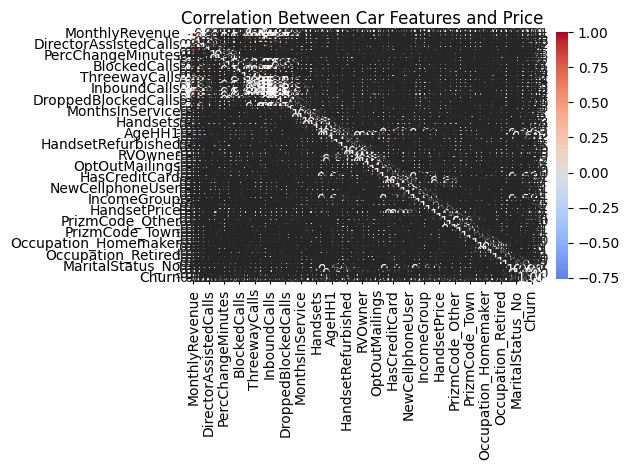

<Figure size 640x480 with 0 Axes>

In [135]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Car Features and Price')
plt.tight_layout()
plt.figure('fig/Correlation Between Car Features and Price')
plt.show()

In [136]:
df.describe()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,Churn
count,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,...,50979.00000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000,50979.000000
mean,58.798914,525.266463,46.821476,0.893171,39.922419,1.229010,-11.523235,-1.182689,6.010406,4.084943,...,0.00308,0.737264,0.171600,0.014339,0.017242,0.007454,0.248769,0.385806,0.365425,0.288315
std,44.425505,529.221765,23.814984,2.220221,96.464659,9.793279,256.555839,39.446428,9.040466,10.950364,...,0.05541,0.440124,0.377036,0.118886,0.130175,0.086015,0.432304,0.486790,0.481554,0.452983
min,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.660000,159.000000,30.000000,0.000000,0.000000,0.000000,-82.000000,-6.900000,0.700000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,1.000000,...,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,70.970000,722.000000,60.000000,0.990000,40.000000,0.200000,65.000000,1.500000,7.700000,3.700000,...,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,384.300000,...,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [137]:
max_values = df.max()
print(max_values.to_string())

ServiceArea                  VAHROA540
MonthlyRevenue                 1223.38
MonthlyMinutes                  7359.0
TotalRecurringCharge             400.0
DirectorAssistedCalls           159.39
OverageMinutes                  4321.0
RoamingCalls                    1112.4
PercChangeMinutes               5192.0
PercChangeRevenues              2483.5
DroppedCalls                     221.7
BlockedCalls                     384.3
UnansweredCalls                  848.7
CustomerCareCalls                327.3
ThreewayCalls                     66.0
ReceivedCalls                   2692.4
OutboundCalls                    644.3
InboundCalls                     519.3
PeakCallsInOut                  2090.7
OffPeakCallsInOut               1474.7
DroppedBlockedCalls              411.7
CallForwardingCalls               81.3
CallWaitingCalls                 212.7
MonthsInService                     61
UniqueSubs                         196
ActiveSubs                          53
Handsets                 

In [138]:
anova_features = [
    'MonthlyRevenue',
    'MonthlyMinutes',
    'TotalRecurringCharge',
    'DirectorAssistedCalls',
    'OverageMinutes',
    'RoamingCalls',
    'PercChangeMinutes',
    'PercChangeRevenues',
    'DroppedCalls',
    'BlockedCalls',
    'UnansweredCalls',
    'CustomerCareCalls',
    'ThreewayCalls',
    'ReceivedCalls',
    'OutboundCalls',
    'InboundCalls',
    'PeakCallsInOut',
    'OffPeakCallsInOut',
    'DroppedBlockedCalls',
    'CallForwardingCalls',
    'CallWaitingCalls',
    'MonthsInService',
    'UniqueSubs',
    'ActiveSubs',
    'Handsets',
    'HandsetModels',
    'CurrentEquipmentDays',
    'AgeHH1',
    'AgeHH2',
    'RetentionCalls',
    'RetentionOffersAccepted',
    'ReferralsMadeBySubscriber',
    'AdjustmentsToCreditRating',
    'HandsetPrice'
]

chi_square_features = [
    'ChildrenInHH',
    'HandsetRefurbished',
    'HandsetWebCapable',
    'TruckOwner',
    'RVOwner',
    'BuysViaMailOrder',
    'RespondsToMailOffers',
    'OptOutMailings',
    'NonUSTravel',
    'OwnsComputer',
    'HasCreditCard',
    'NewCellphoneUser',
    'NotNewCellphoneUser',
    'OwnsMotorcycle',
    'MadeCallToRetentionTeam',
    'PrizmCode_Other',
    'PrizmCode_Rural',
    'PrizmCode_Suburban',
    'PrizmCode_Town',
    'Occupation_Clerical',
    'Occupation_Crafts',
    'Occupation_Homemaker',
    'Occupation_Other',
    'Occupation_Professional',
    'Occupation_Retired',
    'Occupation_Self',
    'Occupation_Student',
    'MaritalStatus_No',
    'MaritalStatus_Unknown',
    'MaritalStatus_Yes',
    'ServiceArea',
    'IncomeGroup',
    'CreditRating'
]

In [139]:
# # Select all rows and all columns EXCEPT the last one for X
# X = df.iloc[:, :-1].values

# # Select all rows and ONLY the last column for y
# y = df.iloc[:, -1].values


In [140]:
train_df, test_df = train_test_split(
    df, 
    test_size=0.20,          # Splits 20% into test, leaving 80% for train
    stratify=df['ServiceArea'],  # Keeps the class distribution identical in both sets
    random_state=42         # Ensures reproducibility
)

In [141]:
anova_results = []

for feature in anova_features:

    group0 = train_df.loc[
        train_df['Churn'] == 0, feature
    ].dropna()

    group1 = train_df.loc[
        train_df['Churn'] == 1, feature
    ].dropna()

    # Skip features with insufficient observations
    if len(group0) < 2 or len(group1) < 2:
        continue

    f_stat, p_value = f_oneway(group0, group1)

    anova_results.append({
        'Feature': feature,
        'F-statistic': f_stat,
        'p-value': p_value
    })

anova_results_df = pd.DataFrame(anova_results)

anova_results_df = anova_results_df.sort_values(
    by='p-value',
    ascending=True
).reset_index(drop=True)

print("ANOVA Results on Training Data")
print(anova_results_df)

ANOVA Results on Training Data
                      Feature  F-statistic       p-value
0        CurrentEquipmentDays   439.149581  5.390627e-97
1              RetentionCalls   165.926918  6.804724e-38
2        TotalRecurringCharge   138.099031  7.804108e-32
3              MonthlyMinutes   105.169441  1.201321e-24
4                  UniqueSubs    78.715713  7.456738e-19
5           OffPeakCallsInOut    70.740725  4.204337e-17
6              PeakCallsInOut    64.281427  1.107084e-15
7               HandsetModels    60.325092  8.228843e-15
8           PercChangeMinutes    56.673688  5.250561e-14
9               ReceivedCalls    54.395417  1.670533e-13
10          CustomerCareCalls    54.264397  1.785555e-13
11               InboundCalls    50.726157  1.079483e-12
12                   Handsets    44.090270  3.175021e-11
13              OutboundCalls    42.537853  7.013643e-11
14    RetentionOffersAccepted    41.235576  1.364252e-10
15            UnansweredCalls    35.757055  2.253765e-09


In [142]:
from scipy.stats import chi2_contingency

chi_results = []

for feature in chi_square_features:

    # Use training data only
    contingency_table = pd.crosstab(
        train_df[feature],
        train_df['Churn']
    )

    # Skip empty or invalid contingency tables
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        continue

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_results.append({
        'Feature': feature,
        'Chi-square': chi2,
        'p-value': p_value,
        'dof': dof
    })

chi_results_df = pd.DataFrame(chi_results)

chi_results_df = chi_results_df.sort_values(
    by='p-value',
    ascending=True
).reset_index(drop=True)

print("Chi-square Results on Training Data")
print(chi_results_df)

Chi-square Results on Training Data
                    Feature  Chi-square       p-value  dof
0   MadeCallToRetentionTeam  185.114170  3.705730e-42    1
1              CreditRating  191.923886  9.919197e-39    6
2         HandsetWebCapable  150.769018  1.177263e-34    1
3        HandsetRefurbished   39.707019  2.950632e-10    1
4               ServiceArea  928.789067  5.064903e-10  679
5     MaritalStatus_Unknown   20.638905  5.545764e-06    1
6          MaritalStatus_No   20.043365  7.570575e-06    1
7      RespondsToMailOffers   13.619575  2.238393e-04    1
8          BuysViaMailOrder   11.246875  7.975719e-04    1
9           PrizmCode_Rural    8.249968  4.075272e-03    1
10              IncomeGroup   23.654962  4.881467e-03    9
11       PrizmCode_Suburban    5.695823  1.700534e-02    1
12       Occupation_Retired    5.325966  2.100996e-02    1
13           PrizmCode_Town    3.982740  4.596872e-02    1
14             ChildrenInHH    3.173460  7.484376e-02    1
15      NotNewCellph

In [143]:
selected_anova_features = anova_results_df[anova_results_df['p-value'] < 0.05]['Feature']
print(selected_anova_features)

0          CurrentEquipmentDays
1                RetentionCalls
2          TotalRecurringCharge
3                MonthlyMinutes
4                    UniqueSubs
5             OffPeakCallsInOut
6                PeakCallsInOut
7                 HandsetModels
8             PercChangeMinutes
9                 ReceivedCalls
10            CustomerCareCalls
11                 InboundCalls
12                     Handsets
13                OutboundCalls
14      RetentionOffersAccepted
15              UnansweredCalls
16                       AgeHH1
17                ThreewayCalls
18             CallWaitingCalls
19        DirectorAssistedCalls
20               OverageMinutes
21              MonthsInService
22                   ActiveSubs
23                       AgeHH2
24    AdjustmentsToCreditRating
25                 RoamingCalls
26          DroppedBlockedCalls
27                 DroppedCalls
28                 HandsetPrice
29    ReferralsMadeBySubscriber
30           PercChangeRevenues
Name: Fe

In [144]:
selected_chi2_features = chi_results_df[chi_results_df['p-value'] < 0.05]['Feature']
print(selected_chi2_features)

0     MadeCallToRetentionTeam
1                CreditRating
2           HandsetWebCapable
3          HandsetRefurbished
4                 ServiceArea
5       MaritalStatus_Unknown
6            MaritalStatus_No
7        RespondsToMailOffers
8            BuysViaMailOrder
9             PrizmCode_Rural
10                IncomeGroup
11         PrizmCode_Suburban
12         Occupation_Retired
13             PrizmCode_Town
Name: Feature, dtype: object


In [145]:
selected_chi2_features = chi_results_df[
    chi_results_df['p-value'] < 0.05
]['Feature'].tolist()

selected_anova_features = anova_results_df[
    anova_results_df['p-value'] < 0.05
]['Feature'].tolist()

# Combine both lists
selected_features = selected_chi2_features + selected_anova_features

# Remove duplicates
selected_features = list(dict.fromkeys(selected_features))

print("Number of selected features:", len(selected_features))
print(selected_features)

Number of selected features: 45
['MadeCallToRetentionTeam', 'CreditRating', 'HandsetWebCapable', 'HandsetRefurbished', 'ServiceArea', 'MaritalStatus_Unknown', 'MaritalStatus_No', 'RespondsToMailOffers', 'BuysViaMailOrder', 'PrizmCode_Rural', 'IncomeGroup', 'PrizmCode_Suburban', 'Occupation_Retired', 'PrizmCode_Town', 'CurrentEquipmentDays', 'RetentionCalls', 'TotalRecurringCharge', 'MonthlyMinutes', 'UniqueSubs', 'OffPeakCallsInOut', 'PeakCallsInOut', 'HandsetModels', 'PercChangeMinutes', 'ReceivedCalls', 'CustomerCareCalls', 'InboundCalls', 'Handsets', 'OutboundCalls', 'RetentionOffersAccepted', 'UnansweredCalls', 'AgeHH1', 'ThreewayCalls', 'CallWaitingCalls', 'DirectorAssistedCalls', 'OverageMinutes', 'MonthsInService', 'ActiveSubs', 'AgeHH2', 'AdjustmentsToCreditRating', 'RoamingCalls', 'DroppedBlockedCalls', 'DroppedCalls', 'HandsetPrice', 'ReferralsMadeBySubscriber', 'PercChangeRevenues']


In [146]:
# Features selected using ANOVA and Chi-square
X_train = train_df[selected_features].copy()
X_test = test_df[selected_features].copy()

# Target variable
y_train = train_df['Churn']
y_test = test_df['Churn']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40783, 45)
X_test shape: (10196, 45)
y_train shape: (40783,)
y_test shape: (10196,)


In [147]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Keep only the selected features
X_train = train_df[selected_features].copy()
X_test = test_df[selected_features].copy()

y_train = train_df['Churn']
y_test = test_df['Churn']

# Identify feature types
categorical_features = X_train.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=['number']
).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['ServiceArea']
Numerical features: ['MadeCallToRetentionTeam', 'CreditRating', 'HandsetWebCapable', 'HandsetRefurbished', 'MaritalStatus_Unknown', 'MaritalStatus_No', 'RespondsToMailOffers', 'BuysViaMailOrder', 'PrizmCode_Rural', 'IncomeGroup', 'PrizmCode_Suburban', 'Occupation_Retired', 'PrizmCode_Town', 'CurrentEquipmentDays', 'RetentionCalls', 'TotalRecurringCharge', 'MonthlyMinutes', 'UniqueSubs', 'OffPeakCallsInOut', 'PeakCallsInOut', 'HandsetModels', 'PercChangeMinutes', 'ReceivedCalls', 'CustomerCareCalls', 'InboundCalls', 'Handsets', 'OutboundCalls', 'RetentionOffersAccepted', 'UnansweredCalls', 'AgeHH1', 'ThreewayCalls', 'CallWaitingCalls', 'DirectorAssistedCalls', 'OverageMinutes', 'MonthsInService', 'ActiveSubs', 'AgeHH2', 'AdjustmentsToCreditRating', 'RoamingCalls', 'DroppedBlockedCalls', 'DroppedCalls', 'HandsetPrice', 'ReferralsMadeBySubscriber', 'PercChangeRevenues']


In [148]:
# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=True
    ))
])

# Combine both transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

In [149]:
print("Missing Churn values in train_df:",
      train_df['Churn'].isna().sum())

print("\nChurn distribution:")
print(train_df['Churn'].value_counts(dropna=False))

Missing Churn values in train_df: 0

Churn distribution:
Churn
0.0    29014
1.0    11769
Name: count, dtype: int64


In [151]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from scipy.stats import loguniform, randint

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'roc_auc'

results = []
best_estimators = {}

def run_search(name, pipeline, params, n_iter):
    """Tune one model, store the result, and print a short summary."""
    print(f'Tuning {name} ...')
    search = RandomizedSearchCV(
        pipeline, params, n_iter=n_iter, scoring=SCORING,
        cv=cv, n_jobs=-1, random_state=42, refit=True, verbose=1,
        error_score='raise')          # show the real error right away if something breaks
    search.fit(X_train, y_train)

    best_estimators[name] = search.best_estimator_
    results.append({'Model': name,
                    f'CV {SCORING}': search.best_score_,
                    'Best params': search.best_params_})
    print(f'{name} best CV {SCORING}: {search.best_score_:.4f}')
    print('Best params:', search.best_params_)
    return search

In [152]:
lr_pipe = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

lr_params = {
    'clf__C': loguniform(1e-3, 1e2),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']
}

lr_search = run_search('LogisticRegression', lr_pipe, lr_params, n_iter=20)

Tuning LogisticRegression ...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [ ]:
# Dense copy of the preprocessor: sparse_threshold=0 forces dense output
dense_preprocessor = clone(preprocessor).set_params(sparse_threshold=0)

hgb_pipe = Pipeline([
    ('preprocessor', dense_preprocessor),
    ('clf', HistGradientBoostingClassifier(
        class_weight='balanced',
        early_stopping=True,
        random_state=42
    ))
])

hgb_params = {
    'clf__learning_rate': loguniform(0.01, 0.3),
    'clf__max_iter': randint(200, 800),
    'clf__max_depth': [None, 3, 5, 7, 10],
    'clf__max_leaf_nodes': randint(15, 63),
    'clf__min_samples_leaf': randint(10, 100),
    'clf__l2_regularization': loguniform(1e-3, 10)
}

hgb_search = run_search('HistGradientBoosting', hgb_pipe, hgb_params, n_iter=25)

In [ ]:
rf_pipe = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('clf', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=1
    ))
])

rf_params = {
    'clf__n_estimators': randint(200, 600),
    'clf__max_depth': [None, 8, 12, 16, 24],
    'clf__min_samples_leaf': randint(1, 20),
    'clf__min_samples_split': randint(2, 30),
    'clf__max_features': ['sqrt', 'log2', 0.3, 0.5]
}

rf_search = run_search('RandomForest', rf_pipe, rf_params, n_iter=25)

In [ ]:
results_df = (pd.DataFrame(results)
              .sort_values(f'CV {SCORING}', ascending=False)
              .reset_index(drop=True))
print(results_df.to_string())

best_name = results_df.loc[0, 'Model']
best_model = best_estimators[best_name]
print(f'\nBest model by cross-validation: {best_name}')

In [ ]:
# ------------------------------------------------------------------
# 4. Final evaluation on the untouched test set (do this ONCE)
# ------------------------------------------------------------------
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('ROC-AUC :', round(roc_auc_score(y_test, y_proba), 4))
print('F1      :', round(f1_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

# ------------------------------------------------------------------
# 5. Save the best model
# ------------------------------------------------------------------
joblib.dump(best_model, f'best_model_{best_name}.joblib')